In [6]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots


import itertools
import random

In [7]:
def load_cycles_from_npz(filename):
	"""
	Loads a flattened .npz file and reconstructs the nested dictionary.
	"""
	data = np.load(filename)
	reconstructed = {}
	
	for key in data.files:
		# Split the key (e.g., 'rough_foot_force')
		# We use rsplit once from the right to handle sensor names with underscores
		parts = key.split('_', 1) 
		if len(parts) < 2: continue
		
		terrain, sensor = parts[0], parts[1]
		
		if terrain not in reconstructed:
			reconstructed[terrain] = {}
		
		# Convert the (N, 100, F) array back into a list of (100, F) arrays
		# This makes it compatible with your existing segment_all_trials output
		reconstructed[terrain][sensor] = [cycle for cycle in data[key]]
		
	print(f"Loaded {len(reconstructed)} terrains from {filename}")
	return reconstructed

# --- Execution ---
dataset = load_cycles_from_npz('walking_terrain_datasets.npz')

Loaded 3 terrains from walking_terrain_datasets.npz


In [8]:
import numpy as np

def split_gait_dataset(dataset, train_ratio=0.8, seed=42):
	"""
	Splits the gait cycle dataset into training and testing sets.
	Safely handles sensors with mismatched cycle counts.
	"""
	random.seed(seed)
	train_set = {}
	test_set = {}

	for terrain in dataset.keys():
		# 1. FIND THE MINIMUM CYCLE COUNT ACROSS ALL SENSORS
		# This ensures we don't try to access an index that doesn't exist for a sensor
		sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
		if not sensor_counts:
			continue
			
		min_cycles = min(sensor_counts)
		
		# 2. Generate indices based on the shortest sensor stream
		indices = list(range(min_cycles))
		random.shuffle(indices)
		
		split_idx = int(min_cycles * train_ratio)
		train_indices = indices[:split_idx]
		test_indices = indices[split_idx:]
		
		train_set[terrain] = {}
		test_set[terrain] = {}

		# 3. Distribute cycles
		for sensor in dataset[terrain].keys():
			all_cycles = dataset[terrain][sensor]
			# We only take the cycles up to min_cycles to stay synchronized
			train_set[terrain][sensor] = [all_cycles[i] for i in train_indices]
			test_set[terrain][sensor] = [all_cycles[i] for i in test_indices]
			
		print(f"Terrain {terrain.upper()}: Used {min_cycles} synchronized cycles. "
			  f"({len(train_indices)} train, {len(test_indices)} test)")

	return train_set, test_set



In [9]:
def format_for_esn(dataset_dict, terrain_to_id_map, sensor_order):
	"""
	Converts the nested dictionary into flat X and y lists for the ESN.
	
	dataset_dict: The output from your split_gait_dataset function.
	terrain_to_id_map: Dictionary mapping string terrain names to integers (e.g., {'concrete': 0, 'grass': 1}).
	sensor_order: A strict list of sensor dictionary keys to ensure columns are always in the same order.
	"""
	X_formatted = []
	y_formatted = []
	
	for terrain, sensors_data in dataset_dict.items():
		if terrain not in terrain_to_id_map:
			continue # Skip terrains we aren't training on
			
		label = terrain_to_id_map[terrain]
		
		# Get the number of cycles for this terrain (they are synchronized)
		n_cycles = len(sensors_data[sensor_order[0]])
		
		for i in range(n_cycles):
			# For cycle 'i', gather data from all 16 joints (K, D, tau)
			cycle_columns = []
			for sensor_name in sensor_order:
				# Ensure it's a numpy array
				sensor_array = np.array(sensors_data[sensor_name][i])
				
				# If the sensor data is 1D (e.g., shape (90,)), reshape to (90, 1) so it stacks horizontally
				if len(sensor_array.shape) == 1:
					sensor_array = sensor_array.reshape(-1, 1)
					
				cycle_columns.append(sensor_array)
			
			# Stack all sensors horizontally to create the (90 timesteps x 48 features) matrix
			full_gait_matrix = np.hstack(cycle_columns)
			
			X_formatted.append(full_gait_matrix)
			y_formatted.append(label)
			
	return X_formatted, np.array(y_formatted)

In [10]:
from env_pred_1 import SupervisedESN
from env_pred_2 import HAPTRClassifier
from env_pred_3 import CNNRNNClassifier
from env_pred_4 import TCNClassifier
from env_pred_5 import SignalTransformerClassifier  

TERRAIN_LABELS = {
	'flat': 0,
	'muddy': 1,
	'water': 2
}

model_list = ["joint_kdf",
			  "leg_kdf",
			  "joint_tor",
			  "leg_grf",
			  "joint_tor_grf"]
sensor_list = [['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'],
			  ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward'],
			  ['joint_torque_fb'],
			  ['foot_force'],
			  ['joint_torque_fb', 'foot_force']]
# model_arch_list = ['esn', 'haptr', 'cnn_rnn', 'tcn', 'strn']
model_arch_list = ['esn', 'haptr', 'cnn_rnn', 'tcn']
model_arch_obj_list = {}
for model_arch in model_arch_list:
	if model_arch == 'esn':
		model_arch_obj_list[model_arch] = SupervisedESN()
	if model_arch == 'haptr':
		model_arch_obj_list[model_arch] = HAPTRClassifier()
	if model_arch == 'cnn_rnn':
		model_arch_obj_list[model_arch] = CNNRNNClassifier()
	if model_arch == 'tcn':
		model_arch_obj_list[model_arch] = TCNClassifier()
	if model_arch == 'strn':
		model_arch_obj_list[model_arch] = SignalTransformerClassifier()



In [11]:
print("Splitting dataset...")
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.5, seed=42)

Splitting dataset...
Terrain FLAT: Used 62 synchronized cycles. (31 train, 31 test)
Terrain MUDDY: Used 59 synchronized cycles. (29 train, 30 test)
Terrain WATER: Used 53 synchronized cycles. (26 train, 27 test)


In [12]:
import numpy as np

# Define the seeds you want to test across
seeds = [42, 100, 2023, 777, 999]
accuracy_dict = {}

for model_arch in model_arch_list:
    model_arch_name = model_arch.upper() if model_arch != 'cnn_rnn' else 'CNN-RNN'
    
    # Initialize the sub-dictionary for this architecture
    if model_arch_name not in accuracy_dict:
        accuracy_dict[model_arch_name] = {}

    for sensor_key, model_file in zip(sensor_list, model_list):
        model_file_name = model_file.replace('_', ' ')
        model_file_name = model_file_name.replace('kdf', 'KDF').replace('grf', 'GRF').replace('tor', 'Torque').replace('joint', 'Joint').replace('leg', 'Leg')
        model_file_name = model_file_name.replace('Torque GRF', 'Torque/Leg GRF')

        print(f"\n=========================================")
        print(f"EVALUATING: {model_arch_name} | {model_file_name}")
        print(f"=========================================")
        print("Booting up Controller and loading weights...")

        # Load the model ONCE for this specific architecture and sensor configuration
        if model_arch == 'esn':
            model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_{model_file}.npz")
        else:
            model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_{model_file}.pt")

        # List to collect accuracies for the current configuration across all seeds
        seed_accuracies = []

        for seed in seeds:
            print(f"  -> Processing Seed: {seed}...")
            
            # 1. Split the dataset using the current seed
            train_data, test_data = split_gait_dataset(dataset, train_ratio=0.5, seed=seed)

            # 2. Format data
            X_train, y_train = format_for_esn(train_data, TERRAIN_LABELS, sensor_key)
            X_test, y_test = format_for_esn(test_data, TERRAIN_LABELS, sensor_key)

            # 3. Evaluate on the newly generated Test Set
            y_pred = []
            for i in range(len(X_test)):
                # Note: Depending on your model implementation, you may only need predicted_class
                predicted_class, _ = model_arch_obj_list[model_arch].predict(X_test[i])
                y_pred.append(predicted_class)

            # 4. Calculate Accuracy for this specific seed
            y_pred = np.array(y_pred)
            correct = np.sum(y_pred == y_test)
            accuracy = (correct / len(X_test)) * 100
            
            seed_accuracies.append(accuracy)
            print(f"     Test Accuracy (Seed {seed}): {accuracy:.2f}%")

        # --- STATISTICAL CALCULATIONS ---
        mean_acc = np.mean(seed_accuracies)
        std_acc = np.std(seed_accuracies)

        print(f"\n[RESULTS] {model_arch_name} ({model_file_name}): Mean = {mean_acc:.2f}%, Std = {std_acc:.2f}%")

        # Store both the mean and std in the dictionary
        accuracy_dict[model_arch_name][model_file_name] = {
            'mean': mean_acc,
            'std': std_acc
        }


EVALUATING: ESN | Joint KDF
Booting up Controller and loading weights...

[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_joint_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 100 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (100, 48)
   • W_res (Reservoir Dynamics): (100, 100)
   • W_out (Reservoir -> Output): (3, 100)
----------------------------------------

  -> Processing Seed: 42...
Terrain FLAT: Used 62 synchronized cycles. (31 train, 31 test)
Terrain MUDDY: Used 59 synchronized cycles. (29 train, 30 test)
Terrain WATER: Used 53 synchronized cycles. (26 train, 27 test)
     Test Accuracy (Seed 42): 94.32%
  -> Processing Seed: 100...
Terrain FLAT: Used 62 synchronized cycles. (31 train, 31 test)
Terrain MUDDY: Used 59 synchronized cycles. (29 train, 30 test)
Terrain WATER: Used 53 synchronized cycles. (26 train, 27 test)
     Test Accuracy (Seed 100): 92.05%
  

# Summary

In [13]:
print("\nFinal Accuracy Comparison:", accuracy_dict)


Final Accuracy Comparison: {'ESN': {'Joint KDF': {'mean': 95.0, 'std': 1.7007533576245186}, 'Leg KDF': {'mean': 95.9090909090909, 'std': 1.1588680712710875}, 'Joint Torque': {'mean': 93.86363636363636, 'std': 2.746146812180584}, 'Leg GRF': {'mean': 90.22727272727273, 'std': 3.0995867493149665}, 'Joint Torque/Leg GRF': {'mean': 92.95454545454545, 'std': 2.8203803740888325}}, 'HAPTR': {'Joint KDF': {'mean': 98.4090909090909, 'std': 0.9090909090909058}, 'Leg KDF': {'mean': 92.95454545454545, 'std': 1.8181818181818201}, 'Joint Torque': {'mean': 92.27272727272728, 'std': 2.6308720233614133}, 'Leg GRF': {'mean': 90.0, 'std': 2.9979331723347533}, 'Joint Torque/Leg GRF': {'mean': 95.0, 'std': 3.261977294183483}}, 'CNN-RNN': {'Joint KDF': {'mean': 97.27272727272728, 'std': 1.5414386325284704}, 'Leg KDF': {'mean': 95.00000000000001, 'std': 1.8463723646899963}, 'Joint Torque': {'mean': 95.22727272727272, 'std': 2.6308720233614142}, 'Leg GRF': {'mean': 93.63636363636364, 'std': 3.4166582678120263

In [14]:
import numpy as np

# Define the seeds you want to test across
seeds = [42, 100, 2023, 777, 999]
accuracy_dict = {}

for model_arch in model_arch_list:
    model_arch_name = model_arch.upper() if model_arch != 'cnn_rnn' else 'CNN-RNN'
    
    # Initialize the sub-dictionary for this architecture
    if model_arch_name not in accuracy_dict:
        accuracy_dict[model_arch_name] = {}

    for sensor_key, model_file in zip(sensor_list, model_list):
        model_file_name = model_file.replace('_', ' ')
        model_file_name = model_file_name.replace('kdf', 'KDF').replace('grf', 'GRF').replace('tor', 'Torque').replace('joint', 'Joint').replace('leg', 'Leg')
        model_file_name = model_file_name.replace('Torque GRF', 'Torque/Leg GRF')

        print(f"\n=========================================")
        print(f"EVALUATING: {model_arch_name} | {model_file_name}")
        print(f"=========================================")
        print("Booting up Controller and loading weights...")

        # Load the model ONCE for this specific architecture and sensor configuration
        if model_arch == 'esn':
            model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_{model_file}.npz")
        else:
            model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_{model_file}.pt")

        # List to collect accuracies for the current configuration across all seeds
        seed_accuracies = []

        for seed in seeds:
            print(f"  -> Processing Seed: {seed}...")
            
            # 1. Split the dataset using the current seed
            train_data, test_data = split_gait_dataset(dataset, train_ratio=0.5, seed=seed)

            # 2. Format data
            X_train, y_train = format_for_esn(train_data, TERRAIN_LABELS, sensor_key)
            X_test, y_test = format_for_esn(test_data, TERRAIN_LABELS, sensor_key)

            # 3. Evaluate on the newly generated Test Set
            y_pred = []
            for i in range(len(X_test)):
                # Note: Depending on your model implementation, you may only need predicted_class
                predicted_class, _ = model_arch_obj_list[model_arch].predict(X_test[i])
                y_pred.append(predicted_class)

            # 4. Calculate Accuracy for this specific seed
            y_pred = np.array(y_pred)
            correct = np.sum(y_pred == y_test)
            accuracy = (correct / len(X_test)) * 100
            
            seed_accuracies.append(accuracy)
            print(f"     Test Accuracy (Seed {seed}): {accuracy:.2f}%")

        # --- STATISTICAL CALCULATIONS ---
        mean_acc = np.mean(seed_accuracies)
        std_acc = np.std(seed_accuracies)

        print(f"\n[RESULTS] {model_arch_name} ({model_file_name}): Mean = {mean_acc:.2f}%, Std = {std_acc:.2f}%")

        # Store both the mean and std in the dictionary
        accuracy_dict[model_arch_name][model_file_name] = {
            'mean': mean_acc,
            'std': std_acc
        }


EVALUATING: ESN | Joint KDF
Booting up Controller and loading weights...

[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_joint_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 100 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (100, 48)
   • W_res (Reservoir Dynamics): (100, 100)
   • W_out (Reservoir -> Output): (3, 100)
----------------------------------------

  -> Processing Seed: 42...
Terrain FLAT: Used 62 synchronized cycles. (31 train, 31 test)
Terrain MUDDY: Used 59 synchronized cycles. (29 train, 30 test)
Terrain WATER: Used 53 synchronized cycles. (26 train, 27 test)
     Test Accuracy (Seed 42): 94.32%
  -> Processing Seed: 100...
Terrain FLAT: Used 62 synchronized cycles. (31 train, 31 test)
Terrain MUDDY: Used 59 synchronized cycles. (29 train, 30 test)
Terrain WATER: Used 53 synchronized cycles. (26 train, 27 test)
     Test Accuracy (Seed 100): 92.05%
  

<Figure size 800x500 with 0 Axes>

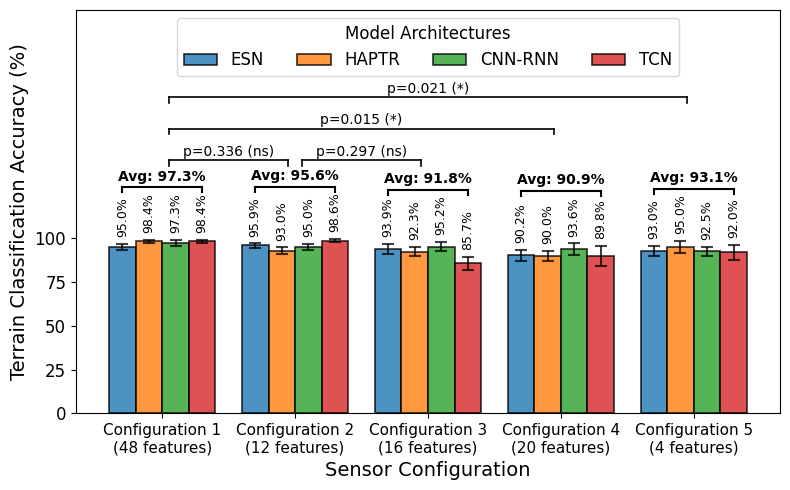

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- Your existing setup ---
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o', 'linestyle': '-'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 's', 'linestyle': '--'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': '^', 'linestyle': '-.'},
    'TCN': {'color': '#d62728', 'marker': 'd', 'linestyle': ':'},
    'STRN': {'color': '#9467bd', 'marker': 'v', 'linestyle': '--'}
}

config_mapping = {
    'Joint KDF': 'Configuration 1\n(48 features)',
    'Leg KDF': 'Configuration 2\n(12 features)',
    'Joint Torque': 'Configuration 3\n(16 features)',
    'Leg GRF': 'Configuration 4\n(20 features)',
    'Joint Torque/Leg GRF': 'Configuration 5\n(4 features)'
}

# 1. Unpack your nested dict into DataFrames
df_mean = pd.DataFrame({model: {config: metrics['mean'] for config, metrics in configs.items()} for model, configs in accuracy_dict.items()})
df_std = pd.DataFrame({model: {config: metrics['std'] for config, metrics in configs.items()} for model, configs in accuracy_dict.items()})

df_mean = df_mean.rename(index=config_mapping)
df_std = df_std.rename(index=config_mapping)
model_colors = [styles[model]['color'] for model in df_mean.columns]

plt.figure(figsize=(8, 5))

# 2. Plot the grouped bar chart
group_width = 0.8
ax = df_mean.plot(
    kind='bar', 
    figsize=(8, 5), 
    width=group_width, 
    color=model_colors, 
    alpha=0.8, 
    edgecolor='black', 
    linewidth=1.2,
    yerr=df_std, 
    error_kw=dict(lw=1.5, capsize=4, capthick=1.5, alpha=0.75, ecolor='black')
)

plt.xlabel('Sensor Configuration', fontsize=14)
plt.ylabel('Terrain Classification Accuracy (%)', fontsize=14)
plt.xticks(rotation=0, fontsize=11) 
plt.legend(title='Model Architectures', fontsize=12, title_fontsize=12, loc='upper center', ncol=5)

# 3. Add individual bar annotations
for i, p in enumerate(ax.patches):
    row_idx = i % len(df_mean)
    col_idx = i // len(df_mean)
    std_val = df_std.iloc[row_idx, col_idx]
    text_y = p.get_height() + std_val
    ax.annotate(
        f"{p.get_height():.1f}%", 
        (p.get_x() + p.get_width() / 2., text_y), 
        ha='center', va='bottom', fontsize=9, color='black', 
        xytext=(0, 5), textcoords='offset points', rotation=90
    )

# 4. Draw the local brace for each Configuration average
num_models = len(df_mean.columns)
bar_width = group_width / num_models
bracket_y_positions = [] 

for i in range(len(df_mean)):
    left_x = i - (group_width / 2) + (bar_width / 2)
    right_x = i + (group_width / 2) - (bar_width / 2)
    
    # Find max height in this group to avoid intersecting error bars
    max_h = max([df_mean.iloc[i, j] + df_std.iloc[i, j] for j in range(num_models)])
            
    bracket_y = max_h + 30 
    bracket_y_positions.append(bracket_y)
    
    ax.plot([left_x, right_x], [bracket_y, bracket_y], color='black', lw=1.5)
    ax.plot([left_x, left_x], [bracket_y - 3, bracket_y], color='black', lw=1.5)
    ax.plot([right_x, right_x], [bracket_y - 3, bracket_y], color='black', lw=1.5)
    
    avg_val = df_mean.iloc[i].mean()
    ax.text(i, bracket_y + 2, f"Avg: {avg_val:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# 5. NEW: Calculate Pairwise p-values and draw leveled overbraces
comparisons = [(0, 1), (0, 3), (1, 2), (0, 4)]

base_overbrace_y = max(bracket_y_positions) + 15  
y_step = 18  # Slightly increased step for better readability between 3 levels
max_used_y = base_overbrace_y

for (idx1, idx2) in comparisons:
    data1 = df_mean.iloc[idx1].values
    data2 = df_mean.iloc[idx2].values
    t_stat, p_val = stats.ttest_rel(data1, data2)
    
    if p_val < 0.001: sig_text = "***"
    elif p_val < 0.01: sig_text = "**"
    elif p_val < 0.05: sig_text = "*"
    else: sig_text = "ns"
        
    p_text = f"p={p_val:.3f} ({sig_text})"
    
    # NEW LOGIC: Calculate the span to determine the vertical level
    span = abs(idx1 - idx2)
    if span == 1:
        level = 0  # Adjacent pairs on the bottom level
    elif span == 3:
        level = 1  # Pairs spanning 2 configurations on the middle level
    else:
        level = 2  # The widest pair (0 to 4) on the top level
        
    current_overbrace_y = base_overbrace_y + (level * y_step)
        
    if current_overbrace_y > max_used_y:
        max_used_y = current_overbrace_y
    
    # Draw overbrace
    ax.plot([idx1+0.05, idx2-0.05], [current_overbrace_y, current_overbrace_y], color='black', lw=1.2)
    ax.plot([idx1+0.05, idx1+0.05], [current_overbrace_y - 3, current_overbrace_y], color='black', lw=1.2)
    ax.plot([idx2-0.05, idx2-0.05], [current_overbrace_y - 3, current_overbrace_y], color='black', lw=1.2)
    
    # Add text
    ax.text((idx1 + idx2) / 2, current_overbrace_y + 1, p_text, ha='center', va='bottom', fontsize=10, color='black')

# 6. Y-Axis Tick Management
# Dynamically set the bounding box to just above the highest brace
plt.ylim(0, max_used_y + 50) 

# Filter out y-ticks that exceed 100%

current_yticks = np.arange(0, 101, 25)
filtered_yticks = [tick for tick in current_yticks if tick <= 100]
plt.yticks(filtered_yticks, fontsize=12)

plt.tight_layout()

# Save and show
plt.savefig('accuracy_barchart.png', dpi=500)
plt.show()

- Test with five class and then re-plot and report.

# Model Size

EXTRACTING MODEL SIZES

[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_joint_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 100 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (100, 48)
   • W_res (Reservoir Dynamics): (100, 100)
   • W_out (Reservoir -> Output): (3, 100)
----------------------------------------


⚙️ ESN Parameter Breakdown:
   • W_in  (100, 48): 4800 weights (Fixed/Non-trainable)
   • W_res (100, 100): 10000 weights (Fixed/Non-trainable)
   • W_out (3, 100): 300 weights (Trainable)
----------------------------------------
Trainable Parameters: 300 (300)


[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_leg_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 500 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (500, 12)
   • W_res (Reservoir Dy

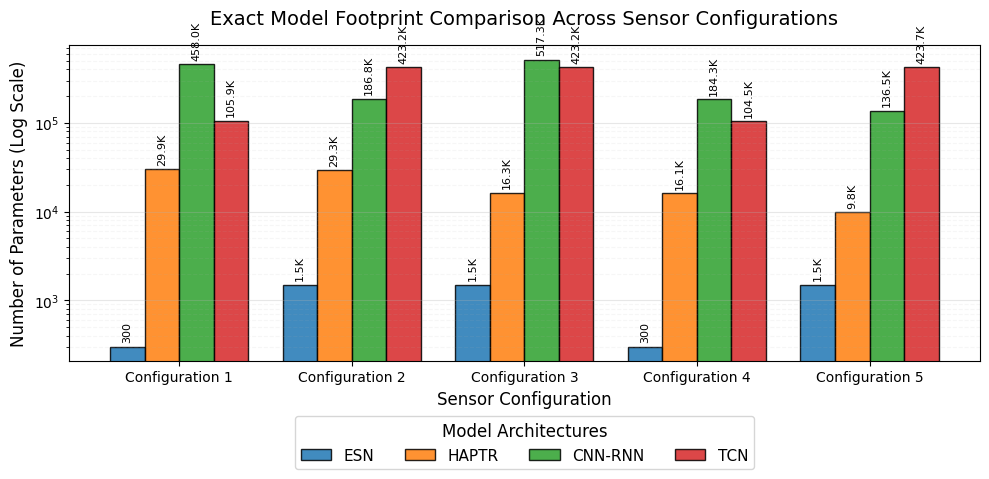

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize a dictionary to store the extracted sizes dynamically
# Format will look like: {'ESN': [size1, size2...], 'HAPTR': [...]}
model_sizes = {}

print("=========================================")
print("EXTRACTING MODEL SIZES")
print("=========================================")

# 2. Loop through and extract sizes
for model_arch in model_arch_list:
    # Format the architecture name for display
    arch_name = model_arch.upper()
    if model_arch == 'cnn_rnn':
        arch_name = 'CNN-RNN'
    elif model_arch == 'signal_transformer' or model_arch == 'strn':
        arch_name = 'STRN'
        
    model_sizes[arch_name] = []
    
    for sensor_key, model_file in zip(sensor_list, model_list):
        
        # Load the model ONCE for this specific architecture and sensor configuration
        if model_arch == 'esn':
            model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_{model_file}.npz")
        else:
            model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_{model_file}.pt")
            
        # Get the exact model size and store it
        size = model_arch_obj_list[model_arch].get_model_size()
        model_sizes[arch_name].append(size)

print("\n=========================================")
print("PLOTTING MODEL SIZE COMPARISON")
print("=========================================")

# 3. Helper function to format numbers (e.g., 1500000 -> 1.5M)
def format_params(num):
    if num >= 1_000_000:
        return f'{num/1_000_000:.1f}M'
    elif num >= 1_000:
        return f'{num/1_000:.1f}K'
    else:
        return str(num)

# 4. Standard mapping for colors and configuration labels
styles = {
    'ESN': '#1f77b4',
    'HAPTR': '#ff7f0e',
    'CNN-RNN': '#2ca02c',
    'TCN': '#d62728',
    'STRN': '#9467bd'
}

config_labels = [
    'Configuration 1', 
    'Configuration 2', 
    'Configuration 3', 
    'Configuration 4', 
    'Configuration 5'
]

# 5. Plotting Logic
fig, ax = plt.subplots(figsize=(10, 5))

# Setup Bar Chart Geometry
x = np.arange(len(config_labels))
num_models = len(model_sizes)
bar_width = 0.8 / num_models  # Dynamically scale width based on how many models are in the dict
offsets = np.linspace(-bar_width * (num_models - 1) / 2, 
                       bar_width * (num_models - 1) / 2, 
                       num_models)

# Draw the bars
for i, (model_name, sizes) in enumerate(model_sizes.items()):
    pos = x + offsets[i]
    color = styles.get(model_name, np.random.rand(3,)) # Fallback color if name doesn't match dict
    bars = ax.bar(pos, sizes, width=bar_width, label=model_name, 
                  color=color, edgecolor='black', linewidth=1, alpha=0.85)
    
    # Add annotations on top of each bar
    for bar in bars:
        height = bar.get_height()
        if height > 0: # Ensure valid heights
            ax.annotate(format_params(int(height)),
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, rotation=90)

# Format the axes
ax.set_yscale('log') # CRITICAL: Log scale for massive size differences
ax.set_ylabel('Number of Parameters (Log Scale)', fontsize=12)
ax.set_xlabel('Sensor Configuration', fontsize=12)
ax.set_title('Exact Model Footprint Comparison Across Sensor Configurations', fontsize=14, pad=15)

ax.set_xticks(x)
ax.set_xticklabels(config_labels[:len(x)], fontsize=10) # Ensure label count matches x-ticks

# Add gridlines to help trace the log scale
ax.grid(True, axis='y', which='major', linestyle='-', alpha=0.3)
ax.grid(True, axis='y', which='minor', linestyle='--', alpha=0.1)

# Add Legend
ax.legend(title='Model Architectures', loc='upper center', bbox_to_anchor=(0.5, -0.15), 
          ncol=5, fontsize=11, title_fontsize=12)

# Ensure layout doesn't clip
plt.tight_layout()

# Save and Show
# plt.savefig('dynamic_model_size_comparison.png', dpi=500, bbox_inches='tight')
plt.show()


[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_joint_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 100 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (100, 48)
   • W_res (Reservoir Dynamics): (100, 100)
   • W_out (Reservoir -> Output): (3, 100)
----------------------------------------


⚙️ ESN Parameter Breakdown:
   • W_in  (100, 48): 4800 weights (Fixed/Non-trainable)
   • W_res (100, 100): 10000 weights (Fixed/Non-trainable)
   • W_out (3, 100): 300 weights (Trainable)
----------------------------------------
Trainable Parameters: 300 (300)


[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_leg_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 500 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (500, 12)
   • W_res (Reservoir Dynamics): (500, 500)
   

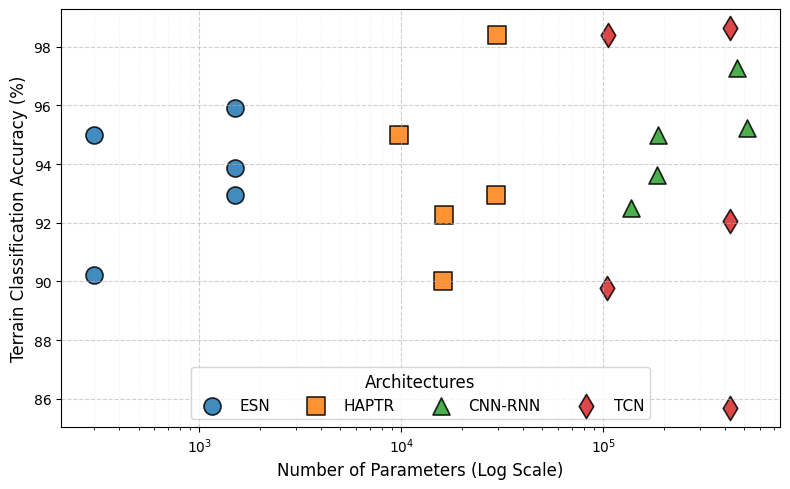

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. EXTRACTING MODEL SIZES
# =========================================
model_sizes = {}

for model_arch in model_arch_list:
    arch_name = model_arch.upper()
    if model_arch == 'cnn_rnn':
        arch_name = 'CNN-RNN'
    elif model_arch in ['signal_transformer', 'strn']:
        arch_name = 'STRN'
        
    model_sizes[arch_name] = []
    
    for sensor_key, model_file in zip(sensor_list, model_list):
        if model_arch == 'esn':
            model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_{model_file}.npz")
        else:
            model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_{model_file}.pt")
            
        size = model_arch_obj_list[model_arch].get_model_size()
        model_sizes[arch_name].append(size)

print("\n=========================================")
print("PLOTTING SIZE VS. ACCURACY SCATTER")
print("=========================================")

# 2. Setup plotting styles
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 's'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': '^'},
    'TCN': {'color': '#d62728', 'marker': 'd'},
    'STRN': {'color': '#9467bd', 'marker': 'v'}
}

fig, ax = plt.subplots(figsize=(8, 5))

# 3. Plotting Logic
for model_name, sizes in model_sizes.items():
    
    # Extract the corresponding accuracies from your existing accuracy_dict
    model_accuracies = []
    for model_file in model_list:
        # Reconstruct the exact dictionary key you used during evaluation
        cfg_name = model_file.replace('_', ' ')
        cfg_name = cfg_name.replace('kdf', 'KDF').replace('grf', 'GRF').replace('tor', 'Torque').replace('joint', 'Joint').replace('leg', 'Leg')
        cfg_name = cfg_name.replace('Torque GRF', 'Torque/Leg GRF')
        
        # Fetch the mean accuracy
        acc = accuracy_dict[model_name][cfg_name]['mean']
        model_accuracies.append(acc)
         
    style = styles.get(model_name, {'color': 'gray', 'marker': 'o'})
    
    # Plot the scatter points for this architecture
    scatter = ax.scatter(sizes, model_accuracies, 
                         label=model_name, 
                         color=style['color'], 
                         marker=style['marker'],
                         s=150,          # Marker size
                         alpha=0.85,     # Transparency
                         edgecolors='black', # Black border for clarity
                         linewidth=1.2)
                         
    # Optional: Annotate each point with its Configuration number (1 through 5)
    # Uncomment the two lines below if you want to explicitly label which dot represents which sensor setup
    # for i, (sz, acc) in enumerate(zip(sizes, model_accuracies)):
    #     ax.annotate(str(i+1), (sz, acc), xytext=(7, 0), textcoords='offset points', fontsize=9, va='center')

# 4. Format the Axes
ax.set_xscale('log') # CRITICAL: Log scale for massive size differences
ax.set_xlabel('Number of Parameters (Log Scale)', fontsize=12)
ax.set_ylabel('Terrain Classification Accuracy (%)', fontsize=12)
# ax.set_title('Accuracy vs. Model Size Trade-off', fontsize=14, pad=15)

# Gridlines
ax.grid(True, which='major', linestyle='--', alpha=0.6)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)

# Legend
ax.legend(title='Architectures', loc='lower center', fontsize=11, title_fontsize=12, ncol=5)

plt.tight_layout()

# Save and Show
# plt.savefig('size_vs_accuracy_scatter.png', dpi=500, bbox_inches='tight')
plt.show()


[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_joint_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 100 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (100, 48)
   • W_res (Reservoir Dynamics): (100, 100)
   • W_out (Reservoir -> Output): (3, 100)
----------------------------------------


⚙️ ESN Parameter Breakdown:
   • W_in  (100, 48): 4800 weights (Fixed/Non-trainable)
   • W_res (100, 100): 10000 weights (Fixed/Non-trainable)
   • W_out (3, 100): 300 weights (Trainable)
----------------------------------------
Trainable Parameters: 300 (300)


[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_leg_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 500 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (500, 12)
   • W_res (Reservoir Dynamics): (500, 500)
   

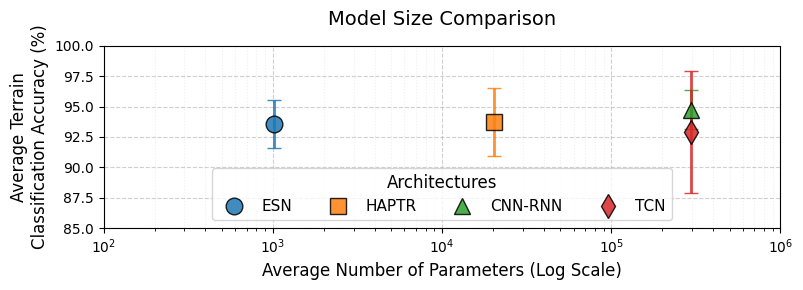

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 1. EXTRACTING MODEL SIZES
# =========================================
model_sizes = {}

for model_arch in model_arch_list:
    arch_name = model_arch.upper()
    if model_arch == 'cnn_rnn':
        arch_name = 'CNN-RNN'
    elif model_arch in ['signal_transformer', 'strn']:
        arch_name = 'STRN'
        
    model_sizes[arch_name] = []
    
    for sensor_key, model_file in zip(sensor_list, model_list):
        if model_arch == 'esn':
            model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_{model_file}.npz")
        else:
            model_arch_obj_list[model_arch].load_model(f"model_{model_arch}/env_pred_{model_arch}_best_{model_file}.pt")
            
        size = model_arch_obj_list[model_arch].get_model_size()
        model_sizes[arch_name].append(size)

print("\n=========================================")
print("PLOTTING AVG SIZE VS. AVG ACCURACY")
print("=========================================")

# 2. Setup plotting styles
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 's'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': '^'},
    'TCN': {'color': '#d62728', 'marker': 'd'},
    'STRN': {'color': '#9467bd', 'marker': 'v'}
}

fig, ax = plt.subplots(figsize=(8, 3))

# 3. Plotting Logic
for model_name, sizes in model_sizes.items():
    
    # Extract the corresponding accuracies from your existing accuracy_dict
    model_accuracies = []
    for model_file in model_list:
        cfg_name = model_file.replace('_', ' ')
        cfg_name = cfg_name.replace('kdf', 'KDF').replace('grf', 'GRF').replace('tor', 'Torque').replace('joint', 'Joint').replace('leg', 'Leg')
        cfg_name = cfg_name.replace('Torque GRF', 'Torque/Leg GRF')
        
        acc = accuracy_dict[model_name][cfg_name]['mean']
        model_accuracies.append(acc)
         
    # --- NEW: Calculate the statistical averages across all 5 configurations ---
    avg_size = np.mean(sizes)
    avg_acc = np.mean(model_accuracies)
    std_acc = np.std(model_accuracies) # Calculate variance across configs
    
    style = styles.get(model_name, {'color': 'gray', 'marker': 'o'})
    
    # Plot using errorbar to show the mean point PLUS the variance
    ax.errorbar(avg_size, avg_acc, yerr=std_acc, 
                label=model_name, 
                color=style['color'], 
                marker=style['marker'],
                markersize=12,           # Large marker for the average point
                alpha=0.85,         
                markeredgecolor='black', # Black border for clarity
                linewidth=2,             # Thickness of the error bar
                capsize=5,               # Caps on the error bars
                linestyle='None')        # Ensure no lines connect different models

# 4. Format the Axes
ax.set_xlim(10**2, 10**6)  # Example: From 100 to 10 Million parameters
ax.set_ylim(85, 100)        # Example: From 0% to 105% accuracy

ax.set_xscale('log') # CRITICAL: Log scale for massive size differences
ax.set_xlabel('Average Number of Parameters (Log Scale)', fontsize=12)
ax.set_ylabel('Average Terrain\nClassification Accuracy (%)', fontsize=12)
ax.set_title('Model Size Comparison', fontsize=14, pad=15)

# Gridlines
ax.grid(True, which='major', linestyle='--', alpha=0.6)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)

# Legend
# --- NEW: Legend without error bars ---
# 1. Get the automatically generated handles and labels
handles, labels = ax.get_legend_handles_labels()

# 2. Extract ONLY the first element of each handle (the marker), ignoring the error lines
clean_handles = [h[0] for h in handles]

# 3. Pass the cleaned handles back into the legend
ax.legend(clean_handles, labels, title='Architectures', loc='lower center', fontsize=11, title_fontsize=12, ncol=5)
plt.tight_layout()

# Save and Show
plt.savefig('avg_size_vs_accuracy.png', dpi=500, bbox_inches='tight')
plt.show()

MEASURING INFERENCE TIMES (WITH WARM-UP)

[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_joint_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 100 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (100, 48)
   • W_res (Reservoir Dynamics): (100, 100)
   • W_out (Reservoir -> Output): (3, 100)
----------------------------------------

[ESN] joint_kdf: 1.50 ms

[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_leg_kdf.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 500 neurons
   • Leak Rate:      0.1
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (500, 12)
   • W_res (Reservoir Dynamics): (500, 500)
   • W_out (Reservoir -> Output): (3, 500)
----------------------------------------

[ESN] leg_kdf: 1.57 ms

[SUCCESS] ESN Model loaded from: 'model_esn/env_pred_esn_best_joint_tor.npz'
---------------

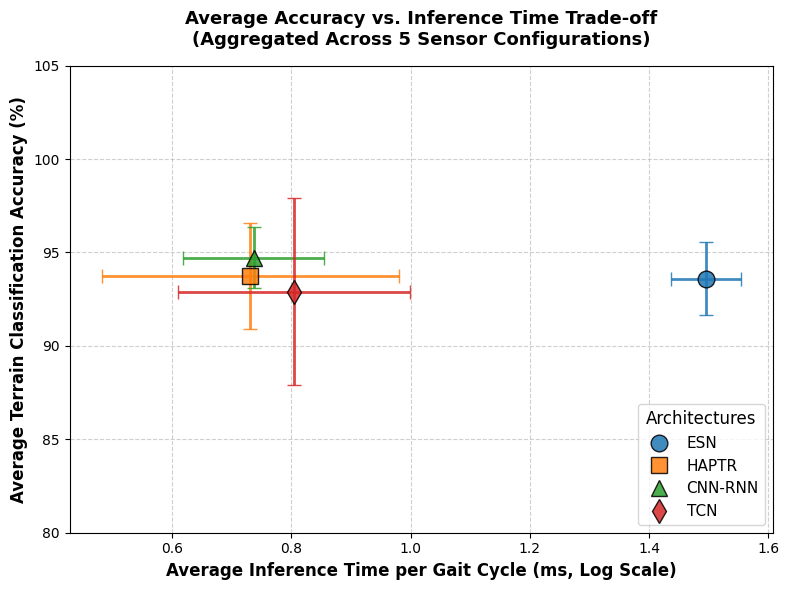

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch

# =========================================
# 1. MEASURING INFERENCE TIMES
# =========================================
model_inference_times = {}

print("=========================================")
print("MEASURING INFERENCE TIMES (WITH WARM-UP)")
print("=========================================")

for model_arch in model_arch_list:
    arch_name = model_arch.upper()
    if model_arch == 'cnn_rnn':
        arch_name = 'CNN-RNN'
    elif model_arch in ['signal_transformer', 'strn']:
        arch_name = 'STRN'
        
    model_inference_times[arch_name] = []
    
    for sensor_key, model_file in zip(sensor_list, model_list):
        model_obj = model_arch_obj_list[model_arch]
        
        # Load the model
        if model_arch == 'esn':
            model_obj.load_model(f"model_{model_arch}/env_pred_{model_arch}_best_{model_file}.npz")
            # Extract input size from ESN W_in shape (n_res, n_inputs)
            n_inputs = model_obj.W_in.shape[1] 
            seq_len = 100 # Default from your previous logs
        else:
            model_obj.load_model(f"model_{model_arch}/env_pred_{model_arch}_best_{model_file}.pt")
            n_inputs = model_obj.n_inputs
            seq_len = model_obj.seq_len

        # Generate a dummy input matching the sensor configuration
        dummy_input = np.random.randn(seq_len, n_inputs).astype(np.float32)
        
        # --- WARM-UP PHASE ---
        # Run 10 predictions without measuring to initialize hardware/CUDA
        for _ in range(10):
            _ = model_obj.predict(dummy_input)
            
        # --- MEASUREMENT PHASE ---
        # Average the time over 100 runs for a stable metric
        n_runs = 100
        start_time = time.perf_counter()
        
        for _ in range(n_runs):
            _ = model_obj.predict(dummy_input)
            
        # If using GPU, wait for operations to finish before stopping the clock
        if hasattr(model_obj, 'device') and model_obj.device.type == 'cuda':
            torch.cuda.synchronize()
            
        end_time = time.perf_counter()
        
        # Calculate average inference time in milliseconds (ms)
        avg_time_ms = ((end_time - start_time) / n_runs) * 1000
        model_inference_times[arch_name].append(avg_time_ms)
        
        print(f"[{arch_name}] {model_file}: {avg_time_ms:.2f} ms")


print("\n=========================================")
print("PLOTTING AVG INFERENCE TIME VS. ACCURACY")
print("=========================================")

# 2. Setup plotting styles
styles = {
    'ESN': {'color': '#1f77b4', 'marker': 'o'},
    'HAPTR': {'color': '#ff7f0e', 'marker': 's'},
    'CNN-RNN': {'color': '#2ca02c', 'marker': '^'},
    'TCN': {'color': '#d62728', 'marker': 'd'},
    'STRN': {'color': '#9467bd', 'marker': 'v'}
}

fig, ax = plt.subplots(figsize=(8, 6))

# 3. Plotting Logic
for model_name, inf_times in model_inference_times.items():
    
    # Extract the corresponding accuracies
    model_accuracies = []
    for model_file in model_list:
        cfg_name = model_file.replace('_', ' ')
        cfg_name = cfg_name.replace('kdf', 'KDF').replace('grf', 'GRF').replace('tor', 'Torque').replace('joint', 'Joint').replace('leg', 'Leg')
        cfg_name = cfg_name.replace('Torque GRF', 'Torque/Leg GRF')
        
        acc = accuracy_dict[model_name][cfg_name]['mean']
        model_accuracies.append(acc)
         
    # Calculate statistical averages and variance across all 5 configurations
    avg_inf_time = np.mean(inf_times)
    std_inf_time = np.std(inf_times) # Optional: X-axis variance
    
    avg_acc = np.mean(model_accuracies)
    std_acc = np.std(model_accuracies) # Y-axis variance
    
    style = styles.get(model_name, {'color': 'gray', 'marker': 'o'})
    
    # Plot using errorbar to show variance in both Time (X) and Accuracy (Y)
    ax.errorbar(avg_inf_time, avg_acc, 
                xerr=std_inf_time,   # Shows how much inference time changes between 48 channels vs 4 channels
                yerr=std_acc,        # Shows how much accuracy drops across configurations
                label=model_name, 
                color=style['color'], 
                marker=style['marker'],
                markersize=12,           
                alpha=0.85,         
                markeredgecolor='black', 
                linewidth=2,             
                capsize=5,               
                linestyle='None')        

# ==========================================
# 4. Format the Axes & Legend
# ==========================================
# Depending on your hardware, inference times might range from 0.1ms to 50ms.
# You can change this to 'linear' if the models run at relatively similar speeds.
# ax.set_xscale('log') 

# Adjust X limits based on your actual measurements (e.g., 0.1ms to 100ms)
# ax.set_xlim(0.1, 100)  
ax.set_ylim(80, 105)        

ax.set_xlabel('Average Inference Time per Gait Cycle (ms, Log Scale)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Terrain Classification Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Average Accuracy vs. Inference Time Trade-off\n(Aggregated Across 5 Sensor Configurations)', fontsize=13, pad=15, fontweight='bold')

# Gridlines
ax.grid(True, which='major', linestyle='--', alpha=0.6)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)

# --- Clean Legend without error bars ---
handles, labels = ax.get_legend_handles_labels()
clean_handles = [h[0] for h in handles]
ax.legend(clean_handles, labels, title='Architectures', loc='lower right', fontsize=11, title_fontsize=12)

plt.tight_layout()

# Save and Show
# plt.savefig('inference_vs_accuracy_scatter.png', dpi=500, bbox_inches='tight')
plt.show()

While the Echo State Network (ESN) requires drastically fewer trainable parameters (only the readout weights) and offers rapid training times, it does not guarantee faster inference in deployment. Our results demonstrate that the ESN's inference latency is heavily bottlenecked by the sequential dense matrix multiplications of its large, fixed reservoir (e.g., 500 neurons). Conversely, modern deep learning architectures like the CNN-RNN benefit from massively parallelized convolutional layers and highly optimized hardware-level kernels (cuDNN), allowing them to process the same temporal gait cycle with lower inference latency despite having more trainable weights.